In [1]:
# Data manipulation
import pandas as pd
import numpy as np
import random

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

# Scikit-learn
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, mean_squared_error

from itertools import product


# SEED GENERATION

In [2]:
SEED=42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# IMPORT DATASET

In [3]:
temp_df=pd.read_csv(r'E:\bridge_cause_analysis\Data\no_supervised_data.csv')
root_df=temp_df
root_df

,Type,Cause,Material,Collapse,Status,Country,Region,Date,temperature_1.9,temperature_1.9.1,temperature_4.5,temperature_7.0,temperature_8.5
0,Beam,Collision events,Reinforced concrete,Total,Operational,Germany,Europe,1966,-0.36346,-0.306055,-0.24865,-0.225425,-0.24865
1,Truss,Collision events,Steel,Total,Operational,Germany,Europe,2015,0.96894,1.784090,1.65721,1.445855,1.41198
2,Truss,Collision events,Steel,Partial,Operational,Germany,Europe,1869,0.40503,0.348125,0.21938,0.244370,0.21938
3,Suspension,Collision events,Wood,Partial,Operational,Germany,Europe,1908,-0.37668,0.055205,-0.03791,-0.281860,-0.05782
4,Beam,Collision events,Reinforced concrete,Total,Operational,Germany,Europe,1979,-0.01883,0.183450,0.26149,0.136105,0.11345
...,...,...,...,...,...,...,...,...,...,...,...,...,...
819,Beam,Construction deficiencies,Reinforced concrete,Total,Construction,Jordan,Asia,2003,1.06424,0.899050,1.01453,1.045700,1.01453
820,Beam,Flood,Composite,Partial,Operational,Lesotho,Africa,2020,1.67965,1.289420,1.18791,1.369190,1.30962
821,Beam,Flood,Reinforced concrete,Total,Operational,Liberia,Africa,2025,1.57352,1.523960,1.32506,1.351885,1.60314
822,Beam,Construction deficiencies,Composite,Total,Operational,Mexico,North America,2022,1.42284,1.466040,1.65549,1.288590,1.42562


# TSNE VISUALIZATION PREPARATION

In [4]:

def plot_tsne(Z, labels, title="t-SNE - Latent Dimension"):
   
    
    le = LabelEncoder()
    y_encoded = le.fit_transform(labels)

    Z_tsne = TSNE(n_components=2, random_state=42).fit_transform(Z)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(Z_tsne[:, 0], Z_tsne[:, 1],
                          c=y_encoded, cmap='viridis', alpha=0.6)

    handles, _ = scatter.legend_elements()
    legend_labels = le.inverse_transform(range(len(handles)))

    plt.legend(handles, legend_labels, title="Cause",
               bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.title(title)
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# Data Selection

In [5]:
columns = list(temp_df.columns)

exclude_cols = ['Date','Type','Cause','Material','Collapse','Status','Country','Region']

num_cols = [col for col in columns if col not in exclude_cols]


print("Numeric columns:", num_cols)


Numeric columns: ['temperature_1.9', 'temperature_1.9.1', 'temperature_4.5', 'temperature_7.0', 'temperature_8.5']


In [6]:
cat_cols = ['Type','Cause','Material','Collapse','Status','Country','Region']


In [7]:
temp_df

,Type,Cause,Material,Collapse,Status,Country,Region,Date,temperature_1.9,temperature_1.9.1,temperature_4.5,temperature_7.0,temperature_8.5
0,Beam,Collision events,Reinforced concrete,Total,Operational,Germany,Europe,1966,-0.36346,-0.306055,-0.24865,-0.225425,-0.24865
1,Truss,Collision events,Steel,Total,Operational,Germany,Europe,2015,0.96894,1.784090,1.65721,1.445855,1.41198
2,Truss,Collision events,Steel,Partial,Operational,Germany,Europe,1869,0.40503,0.348125,0.21938,0.244370,0.21938
3,Suspension,Collision events,Wood,Partial,Operational,Germany,Europe,1908,-0.37668,0.055205,-0.03791,-0.281860,-0.05782
4,Beam,Collision events,Reinforced concrete,Total,Operational,Germany,Europe,1979,-0.01883,0.183450,0.26149,0.136105,0.11345
...,...,...,...,...,...,...,...,...,...,...,...,...,...
819,Beam,Construction deficiencies,Reinforced concrete,Total,Construction,Jordan,Asia,2003,1.06424,0.899050,1.01453,1.045700,1.01453
820,Beam,Flood,Composite,Partial,Operational,Lesotho,Africa,2020,1.67965,1.289420,1.18791,1.369190,1.30962
821,Beam,Flood,Reinforced concrete,Total,Operational,Liberia,Africa,2025,1.57352,1.523960,1.32506,1.351885,1.60314
822,Beam,Construction deficiencies,Composite,Total,Operational,Mexico,North America,2022,1.42284,1.466040,1.65549,1.288590,1.42562


# Ordinal Encoder

In [8]:



encoder = OrdinalEncoder()

X_encoded = encoder.fit_transform(temp_df[cat_cols])


# %%
X_encoded_df = pd.DataFrame(X_encoded, columns=encoder.get_feature_names_out(cat_cols), index=temp_df.index)
X_encoded_df

X_encoded_df = pd.concat(
    [temp_df.drop(columns=cat_cols), X_encoded_df],
    axis=1
)




In [9]:
temp_df

,Type,Cause,Material,Collapse,Status,Country,Region,Date,temperature_1.9,temperature_1.9.1,temperature_4.5,temperature_7.0,temperature_8.5
0,Beam,Collision events,Reinforced concrete,Total,Operational,Germany,Europe,1966,-0.36346,-0.306055,-0.24865,-0.225425,-0.24865
1,Truss,Collision events,Steel,Total,Operational,Germany,Europe,2015,0.96894,1.784090,1.65721,1.445855,1.41198
2,Truss,Collision events,Steel,Partial,Operational,Germany,Europe,1869,0.40503,0.348125,0.21938,0.244370,0.21938
3,Suspension,Collision events,Wood,Partial,Operational,Germany,Europe,1908,-0.37668,0.055205,-0.03791,-0.281860,-0.05782
4,Beam,Collision events,Reinforced concrete,Total,Operational,Germany,Europe,1979,-0.01883,0.183450,0.26149,0.136105,0.11345
...,...,...,...,...,...,...,...,...,...,...,...,...,...
819,Beam,Construction deficiencies,Reinforced concrete,Total,Construction,Jordan,Asia,2003,1.06424,0.899050,1.01453,1.045700,1.01453
820,Beam,Flood,Composite,Partial,Operational,Lesotho,Africa,2020,1.67965,1.289420,1.18791,1.369190,1.30962
821,Beam,Flood,Reinforced concrete,Total,Operational,Liberia,Africa,2025,1.57352,1.523960,1.32506,1.351885,1.60314
822,Beam,Construction deficiencies,Composite,Total,Operational,Mexico,North America,2022,1.42284,1.466040,1.65549,1.288590,1.42562


In [10]:
X_encoded_df=X_encoded_df[num_cols+cat_cols]
X_encoded_df

,temperature_1.9,temperature_1.9.1,temperature_4.5,temperature_7.0,temperature_8.5,Type,Cause,Material,Collapse,Status,Country,Region
0,-0.36346,-0.306055,-0.24865,-0.225425,-0.24865,1.0,0.0,5.0,1.0,1.0,47.0,6.0
1,0.96894,1.784090,1.65721,1.445855,1.41198,6.0,0.0,7.0,1.0,1.0,47.0,6.0
2,0.40503,0.348125,0.21938,0.244370,0.21938,6.0,0.0,7.0,0.0,1.0,47.0,6.0
3,-0.37668,0.055205,-0.03791,-0.281860,-0.05782,4.0,0.0,8.0,0.0,1.0,47.0,6.0
4,-0.01883,0.183450,0.26149,0.136105,0.11345,1.0,0.0,5.0,1.0,1.0,47.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...
819,1.06424,0.899050,1.01453,1.045700,1.01453,1.0,1.0,5.0,1.0,0.0,65.0,1.0
820,1.67965,1.289420,1.18791,1.369190,1.30962,1.0,4.0,1.0,0.0,1.0,71.0,0.0
821,1.57352,1.523960,1.32506,1.351885,1.60314,1.0,4.0,5.0,1.0,1.0,72.0,0.0
822,1.42284,1.466040,1.65549,1.288590,1.42562,1.0,1.0,1.0,1.0,1.0,82.0,7.0


# VISUALIZATION ORIGINAL SPACE

C:\Users\Elias\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Elias\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\Elias\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
   

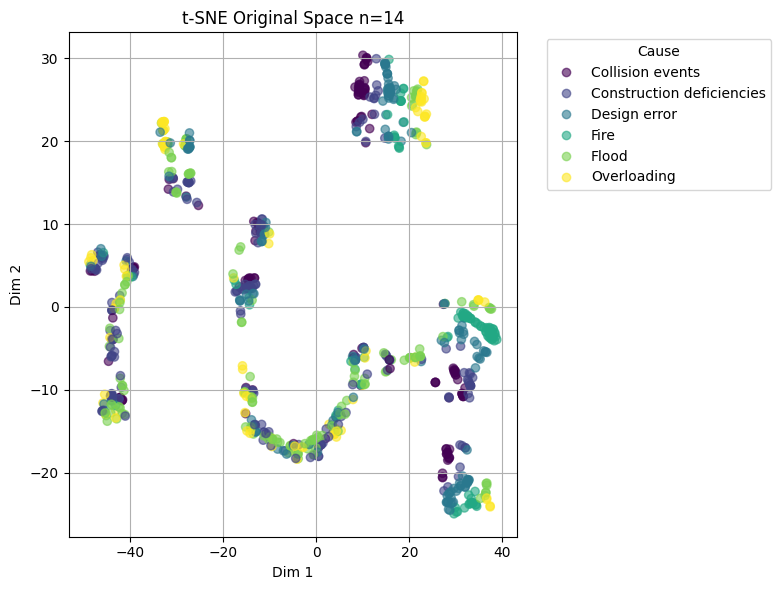

In [11]:
plot_tsne(X_encoded_df,temp_df['Cause'],'t-SNE Original Space n=14')

In [12]:
r_columns=['Collapse','Status','Region','Country']
X_encoded_df=X_encoded_df.drop(r_columns,axis=1)
X_encoded_df

,temperature_1.9,temperature_1.9.1,temperature_4.5,temperature_7.0,temperature_8.5,Type,Cause,Material
0,-0.36346,-0.306055,-0.24865,-0.225425,-0.24865,1.0,0.0,5.0
1,0.96894,1.784090,1.65721,1.445855,1.41198,6.0,0.0,7.0
2,0.40503,0.348125,0.21938,0.244370,0.21938,6.0,0.0,7.0
3,-0.37668,0.055205,-0.03791,-0.281860,-0.05782,4.0,0.0,8.0
4,-0.01883,0.183450,0.26149,0.136105,0.11345,1.0,0.0,5.0
...,...,...,...,...,...,...,...,...
819,1.06424,0.899050,1.01453,1.045700,1.01453,1.0,1.0,5.0
820,1.67965,1.289420,1.18791,1.369190,1.30962,1.0,4.0,1.0
821,1.57352,1.523960,1.32506,1.351885,1.60314,1.0,4.0,5.0
822,1.42284,1.466040,1.65549,1.288590,1.42562,1.0,1.0,1.0


In [13]:
stratify_col = temp_df["Cause"]

X_train, X_val = train_test_split(
    X_encoded_df,
    test_size=0.2,
    random_state=SEED,
    stratify=stratify_col
)

X_train_root, X_val_root = train_test_split(
    temp_df,
    test_size=0.2,
    random_state=SEED,
    stratify=stratify_col
)


# Autoencoder Implmentation

Latent dim = 3, Validation Loss final = 0.648679
Latent dim = 4, Validation Loss final = 0.257192
Latent dim = 5, Validation Loss final = 0.062698
Latent dim = 6, Validation Loss final = 0.252964
Latent dim = 7, Validation Loss final = 0.063417


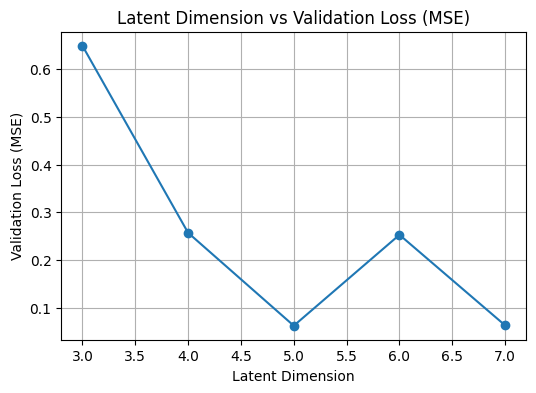


Best latent dim: 5


In [14]:


latent_dims = [ 3,4, 5,6, 7]
val_losses_final = []

input_dim = X_train.shape[1]

best_val_loss = float('inf')
best_model = None
best_latent_dim = None
best_history = None

all_models = {}
all_histories = {}

for dim in latent_dims:

    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    input_layer = layers.Input(shape=(input_dim,))
    x = layers.Dense(8, activation='relu')(input_layer)
    latent = layers.Dense(
        dim, activation='relu',
        activity_regularizer=regularizers.l1(1e-4)
    )(x)
    x = layers.Dense(8, activation='relu')(latent)
    output_layer = layers.Dense(input_dim, activation='linear')(x)

    autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
    autoencoder.compile(optimizer='adam', loss='mse')

    # Train
    history = autoencoder.fit(
        X_train, X_train,
        validation_data=(X_val, X_val),
        epochs=100,
        batch_size=32,
        shuffle=True,
        verbose=0
    )

    val_loss_final = history.history['val_loss'][-1]
    val_losses_final.append(val_loss_final)

    print(f"Latent dim = {dim}, Validation Loss final = {val_loss_final:.6f}")

    # Save model + history
    all_models[dim] = autoencoder
    all_histories[dim] = history

    if val_loss_final < best_val_loss:
        best_val_loss = val_loss_final
        best_latent_dim = dim
        best_model = autoencoder
        best_history = history

# Plot results
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(latent_dims, val_losses_final, marker='o')
plt.title("Latent Dimension vs Validation Loss (MSE)")
plt.xlabel("Latent Dimension")
plt.ylabel("Validation Loss (MSE)")
plt.grid(True)
plt.show()

print("\nBest latent dim:", best_latent_dim)


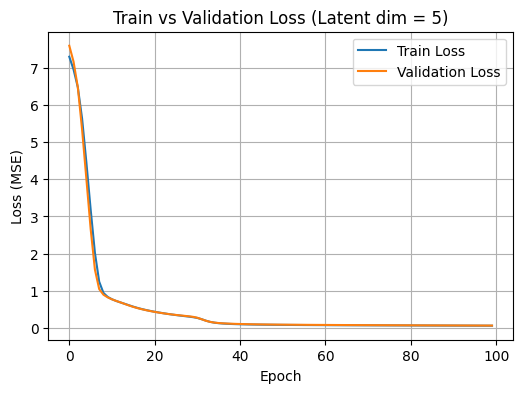

In [15]:
plt.figure(figsize=(6,4))
plt.plot(best_history.history['loss'], label='Train Loss')
plt.plot(best_history.history['val_loss'], label='Validation Loss')
plt.title(f"Train vs Validation Loss (Latent dim = {best_latent_dim})")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
def extract_encoder_from_autoencoder(autoencoder, latent_dim):
    encoder = models.Model(
        inputs=autoencoder.input, 
        outputs=autoencoder.layers[2].output  
    )
    return encoder


In [17]:
print("Best Latent_DIM: "+str(best_latent_dim))

Best Latent_DIM: 5


In [18]:
dim=best_latent_dim
autoencoder = all_models[dim]
encoder = extract_encoder_from_autoencoder(autoencoder, dim)

Z_dim = encoder.predict(X_train)
Z_dim_val=encoder.predict(X_val)


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [19]:
print(Z_dim.shape)
print(Z_dim_val.shape)


(659, 5)
(165, 5)


# Visualiztion After Autoencoder

In [20]:

def plot_tsne(Z, labels, title="t-SNE - Latent Dimension"):
   
    
    le = LabelEncoder()
    y_encoded = le.fit_transform(labels)

    Z_tsne = TSNE(n_components=2, random_state=42).fit_transform(Z)

    # Graficar
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(Z_tsne[:, 0], Z_tsne[:, 1],
                          c=y_encoded, cmap='viridis', alpha=0.6)

    handles, _ = scatter.legend_elements()
    legend_labels = le.inverse_transform(range(len(handles)))

    plt.legend(handles, legend_labels, title="Cause",
               bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.title(title)
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


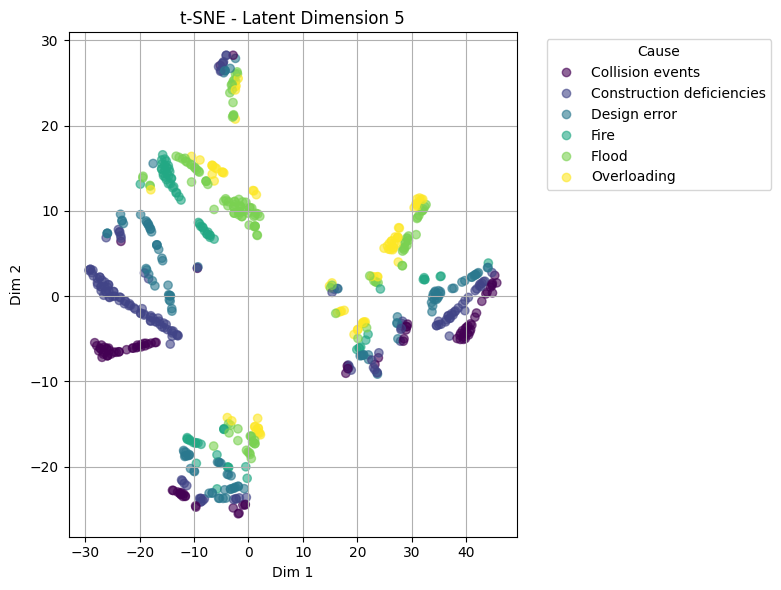

In [21]:
plot_tsne(Z_dim,X_train_root['Cause'],'t-SNE - Latent Dimension 5')

In [22]:
#SAVING Z  TEST LATENT

np.save("Z_latent.npy", Z_dim_val)

# GRID SEARCH TRAINING

In [138]:
def optimize_clustering(X, cluster_range=[2,3,4,5]):
    param_grid = {
        "KMeans": {"n_init": [10, 20, 30, 40], "max_iter": [300, 600]},
        "Agglomerative": {"linkage": ["ward", "average", "complete"], "metric": ["euclidean"]},
        "Spectral": {"affinity": ["nearest_neighbors", "rbf"], "assign_labels": ["kmeans", "discretize"]},
        "GaussianMixture": {"covariance_type": ["full", "tied", "diag", "spherical"]}
    }

    results = []

    for k in cluster_range:
        for model_name in ["KMeans", "Agglomerative", "Spectral", "GaussianMixture"]:
            grid = param_grid[model_name]
            
            for params in (dict(zip(grid.keys(), values)) for values in product(*grid.values())):
                try:
                    # -----------------------------
                    # Build model
                    # -----------------------------
                    if model_name == "KMeans":
                        model = KMeans(n_clusters=k, random_state=42, **params)

                    elif model_name == "Agglomerative":
                        linkage = params["linkage"]
                        if linkage == "ward":
                            model = AgglomerativeClustering(n_clusters=k, linkage="ward")
                        else:
                            model = AgglomerativeClustering(
                                n_clusters=k, linkage=linkage, metric=params["metric"]
                            )

                    elif model_name == "Spectral":
                        model = SpectralClustering(
                            n_clusters=k, random_state=42, **params
                        )

                    elif model_name == "GaussianMixture":
                        model = GaussianMixture(
                            n_components=k, random_state=42, **params
                        )

                    # -----------------------------
                    # Fit / Predict
                    # -----------------------------
                    if model_name == "GaussianMixture":
                        model.fit(X)
                        labels = model.predict(X)
                        inertia = None
                        aic = model.aic(X)
                        bic = model.bic(X)

                    elif model_name == "KMeans":
                        model.fit(X)
                        labels = model.labels_
                        inertia = model.inertia_
                        aic = None
                        bic = None

                    else:
                        labels = model.fit_predict(X)
                        inertia = None
                        aic = None
                        bic = None

                    # -----------------------------
                    # Metrics
                    # -----------------------------
                    try:
                        sil = silhouette_score(X, labels)
                    except:
                        sil = np.nan

                    try:
                        db = davies_bouldin_score(X, labels)
                    except:
                        db = np.nan

                    try:
                        ch = calinski_harabasz_score(X, labels)
                    except:
                        ch = np.nan

                    # -----------------------------
                    # Store results
                    # -----------------------------
                    row = {
                        "Model": model_name,
                        "Clusters": k,
                        "Params": params,
                        "Labels": labels,
                        "Inertia": inertia,   # used for KMeans elbow
                        "AIC": aic,            # for GMM elbow
                        "BIC": bic,            # for GMM elbow
                        "Silhouette": sil,
                        "DB": db,
                        "CH": ch,
                        "TrainedModel": model
                    }

                    results.append(row)

                except Exception as e:
                    print(f"⚠ Error: {model_name}, k={k}, params={params}: {e}")

    return pd.DataFrame(results)

In [139]:

# def optimize_clustering(X, cluster_range=[2,3,4,5]):
#     param_grid = {
#         "KMeans": {"n_init": [10, 20, 30, 40], "max_iter": [300, 600]},
#         "Agglomerative": {"linkage": ["ward", "average", "complete"], "metric": ["euclidean"]},
#         "Spectral": {"affinity": ["nearest_neighbors", "rbf"], "assign_labels": ["kmeans", "discretize"]},
#         "GaussianMixture": {"covariance_type": ["full", "tied", "diag", "spherical"]}
#     }

#     results = []

#     for k in cluster_range:
#         for model_name in ["KMeans", "Agglomerative", "Spectral", "GaussianMixture"]:
#             grid = param_grid[model_name]
            
#             for params in (dict(zip(grid.keys(), values)) for values in product(*grid.values())):
#                 try:
#                     # -----------------------------
#                 # Build model
#                     # -----------------------------
#                     if model_name == "KMeans":
#                         model = KMeans(n_clusters=k, random_state=42, **params)

#                     elif model_name == "Agglomerative":
#                         linkage = params["linkage"]
#                         if linkage == "ward":
#                             model = AgglomerativeClustering(n_clusters=k, linkage="ward")
#                         else:
#                             model = AgglomerativeClustering(
#                                 n_clusters=k, linkage=linkage, metric=params["metric"]
#                             )

#                     elif model_name == "Spectral":
#                         model = SpectralClustering(
#                             n_clusters=k, random_state=42, **params
#                         )

#                     elif model_name == "GaussianMixture":
#                         model = GaussianMixture(
#                             n_components=k, random_state=42, **params
#                         )

#                     # -----------------------------
#                     # Fit / Predict
#                     # -----------------------------
#                     if model_name == "GaussianMixture":
#                         model.fit(X)
#                         labels = model.predict(X)
#                         inertia = None
#                         aic = model.aic(X)
#                         bic = model.bic(X)

#                     elif model_name == "KMeans":
#                         model.fit(X)
#                         labels = model.labels_
#                         inertia = model.inertia_
#                         aic = None
#                         bic = None

#                     else:
#                         labels = model.fit_predict(X)
#                         inertia = None
#                         aic = None
#                         bic = None

#                     # -----------------------------
#                     # Metrics
#                     # -----------------------------
#                     try:
#                         sil = silhouette_score(X, labels)
#                     except:
#                         sil = np.nan

#                     try:
#                         db = davies_bouldin_score(X, labels)
#                     except:
#                         db = np.nan

#                     try:
#                         ch = calinski_harabasz_score(X, labels)
#                     except:
#                         ch = np.nan

#                     # -----------------------------
#                     # Store results
#                     # -----------------------------
#                     row = {
#                         "Model": model_name,
#                         "Clusters": k,
#                         "Params": params,
#                         "Labels": labels,
#                         "Inertia": inertia,   # used for KMeans elbow
#                         "AIC": aic,            # for GMM elbow
#                         "BIC": bic,            # for GMM elbow
#                         "Silhouette": sil,
#                         "DB": db,
#                         "CH": ch,
#                         "TrainedModel": model
#                     }

#                     results.append(row)

#                 except Exception as e:
#                     print(f"⚠ Error: {model_name}, k={k}, params={params}: {e}")

#     return pd.DataFrame(results)


### AE DATA TRAIN


In [140]:
df_raw_z=optimize_clustering(Z_dim, cluster_range=[2, 3, 4, 5,6])
df_raw_z

,Model,Clusters,Params,Labels,Inertia,AIC,BIC,Silhouette,DB,CH,TrainedModel
0,KMeans,2,"{'n_init': 10, 'max_iter': 300}","[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, ...",1932.644897,NaN,NaN,0.616693,0.567549,1494.994995,"KMeans(n_clusters=2, n_init=10, random_state=42)"
1,KMeans,2,"{'n_init': 10, 'max_iter': 600}","[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, ...",1932.644897,NaN,NaN,0.616693,0.567549,1494.994995,"KMeans(max_iter=600, n_clusters=2, n_init=10, ..."
2,KMeans,2,"{'n_init': 20, 'max_iter': 300}","[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, ...",1932.644897,NaN,NaN,0.616693,0.567549,1494.994995,"KMeans(n_clusters=2, n_init=20, random_state=42)"
3,KMeans,2,"{'n_init': 20, 'max_iter': 600}","[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, ...",1932.644897,NaN,NaN,0.616693,0.567549,1494.994995,"KMeans(max_iter=600, n_clusters=2, n_init=20, ..."
4,KMeans,2,"{'n_init': 30, 'max_iter': 300}","[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, ...",1932.644897,NaN,NaN,0.616693,0.567549,1494.994995,"KMeans(n_clusters=2, n_init=30, random_state=42)"
...,...,...,...,...,...,...,...,...,...,...,...
90,Spectral,6,"{'affinity': 'rbf', 'assign_labels': 'discreti...","[0, 4, 0, 5, 4, 0, 0, 0, 5, 0, 4, 5, 0, 0, 0, ...",NaN,NaN,NaN,0.386310,0.943158,543.721252,"SpectralClustering(assign_labels='discretize',..."
91,GaussianMixture,6,{'covariance_type': 'full'},"[0, 1, 3, 1, 1, 0, 3, 0, 1, 0, 1, 1, 0, 3, 0, ...",NaN,351.606537,912.946979,0.099884,2.454931,349.969604,"GaussianMixture(n_components=6, random_state=42)"
92,GaussianMixture,6,{'covariance_type': 'tied'},"[3, 5, 3, 1, 5, 0, 0, 3, 1, 3, 5, 1, 0, 0, 3, ...",NaN,3939.642078,4164.178254,0.245315,1.289281,444.810181,"GaussianMixture(covariance_type='tied', n_comp..."
93,GaussianMixture,6,{'covariance_type': 'diag'},"[3, 5, 0, 1, 5, 0, 0, 3, 5, 3, 5, 1, 0, 0, 3, ...",NaN,6749.100209,7040.997238,0.284828,1.224576,559.451355,"GaussianMixture(covariance_type='diag', n_comp..."


In [141]:
import pandas as pd

def clustering_stats_by_model_k(
    df,
    model_col='Model',
    k_col='Clusters',
    silhouette_col='Silhouette',
    db_col='DB',
    ch_col='CH',
    drop_na=True
):

    data = df.copy()

    if drop_na:
        data = data.dropna(subset=[silhouette_col, db_col, ch_col])

    stats = (
        data
        .groupby([model_col, k_col])
        .agg(
            Silhouette_mean=(silhouette_col, 'mean'),
            Silhouette_std=(silhouette_col, 'std'),
            DB_mean=(db_col, 'mean'),
            DB_std=(db_col, 'std'),
            CH_mean=(ch_col, 'mean'),
            CH_std=(ch_col, 'std')
        )
        .reset_index()
    )

    return stats


In [142]:
silhouette_stats_z = clustering_stats_by_model_k(df_raw_z)
silhouette_stats_z


,Model,Clusters,Silhouette_mean,Silhouette_std,DB_mean,DB_std,CH_mean,CH_std
0,Agglomerative,2,0.615072,0.001333,0.563902,0.006287,1475.721069,0.578901
1,Agglomerative,3,0.451324,0.045703,0.918931,0.232672,900.210632,61.490067
2,Agglomerative,4,0.415676,0.072960,0.959477,0.171620,716.079346,30.067535
3,Agglomerative,5,0.392279,0.034114,1.010902,0.150741,615.038635,68.243073
4,Agglomerative,6,0.294044,0.046199,1.125886,0.228855,548.500366,86.025955
5,GaussianMixture,2,0.608513,0.012024,0.594625,0.033610,1426.488159,104.421562
6,GaussianMixture,3,0.458459,0.027854,1.197002,0.084113,826.402344,57.391018
7,GaussianMixture,4,0.273434,0.060729,1.744050,0.718769,679.352722,122.573875
8,GaussianMixture,5,0.251332,0.078986,1.648680,0.653247,581.233765,122.971741
9,GaussianMixture,6,0.229343,0.088426,1.534516,0.615567,481.573303,104.760490


### NO AE TRAIN

In [143]:
X_encoded_df

,temperature_1.9,temperature_1.9.1,temperature_4.5,temperature_7.0,temperature_8.5,Type,Cause,Material
0,-0.36346,-0.306055,-0.24865,-0.225425,-0.24865,1.0,0.0,5.0
1,0.96894,1.784090,1.65721,1.445855,1.41198,6.0,0.0,7.0
2,0.40503,0.348125,0.21938,0.244370,0.21938,6.0,0.0,7.0
3,-0.37668,0.055205,-0.03791,-0.281860,-0.05782,4.0,0.0,8.0
4,-0.01883,0.183450,0.26149,0.136105,0.11345,1.0,0.0,5.0
...,...,...,...,...,...,...,...,...
819,1.06424,0.899050,1.01453,1.045700,1.01453,1.0,1.0,5.0
820,1.67965,1.289420,1.18791,1.369190,1.30962,1.0,4.0,1.0
821,1.57352,1.523960,1.32506,1.351885,1.60314,1.0,4.0,5.0
822,1.42284,1.466040,1.65549,1.288590,1.42562,1.0,1.0,1.0


In [144]:
df_raw_x=optimize_clustering(X_train, cluster_range=[2, 3, 4, 5,6])
df_raw_x

,Model,Clusters,Params,Labels,Inertia,AIC,BIC,Silhouette,DB,CH,TrainedModel
0,KMeans,2,"{'n_init': 10, 'max_iter': 300}","[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, ...",4688.511791,NaN,NaN,0.433333,1.013702,503.159718,"KMeans(n_clusters=2, n_init=10, random_state=42)"
1,KMeans,2,"{'n_init': 10, 'max_iter': 600}","[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, ...",4688.511791,NaN,NaN,0.433333,1.013702,503.159718,"KMeans(max_iter=600, n_clusters=2, n_init=10, ..."
2,KMeans,2,"{'n_init': 20, 'max_iter': 300}","[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, ...",4688.511791,NaN,NaN,0.433333,1.013702,503.159718,"KMeans(n_clusters=2, n_init=20, random_state=42)"
3,KMeans,2,"{'n_init': 20, 'max_iter': 600}","[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, ...",4688.511791,NaN,NaN,0.433333,1.013702,503.159718,"KMeans(max_iter=600, n_clusters=2, n_init=20, ..."
4,KMeans,2,"{'n_init': 30, 'max_iter': 300}","[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, ...",4688.511791,NaN,NaN,0.433333,1.013702,503.159718,"KMeans(n_clusters=2, n_init=30, random_state=42)"
...,...,...,...,...,...,...,...,...,...,...,...
90,Spectral,6,"{'affinity': 'rbf', 'assign_labels': 'discreti...","[0, 1, 0, 3, 1, 0, 0, 0, 3, 0, 1, 3, 0, 0, 0, ...",NaN,NaN,NaN,0.349745,0.953042,218.274700,"SpectralClustering(assign_labels='discretize',..."
91,GaussianMixture,6,{'covariance_type': 'full'},"[1, 3, 4, 3, 3, 1, 1, 1, 5, 0, 3, 3, 1, 4, 4, ...",NaN,-2027.914539,-819.909908,0.140930,1.945999,144.224839,"GaussianMixture(n_components=6, random_state=42)"
92,GaussianMixture,6,{'covariance_type': 'tied'},"[1, 2, 4, 3, 2, 4, 4, 1, 3, 1, 2, 3, 4, 4, 1, ...",NaN,3593.836331,3993.510726,0.239664,1.742114,204.997420,"GaussianMixture(covariance_type='tied', n_comp..."
93,GaussianMixture,6,{'covariance_type': 'diag'},"[2, 3, 1, 3, 3, 4, 1, 0, 5, 1, 3, 3, 2, 1, 4, ...",NaN,7373.015653,7826.578730,0.105812,2.365965,128.567734,"GaussianMixture(covariance_type='diag', n_comp..."


In [ ]:
silhouette_stats_x=clustering_stats_by_model_k(df_raw_x)
silhouette_stats_x


,Model,Clusters,Silhouette_mean,Silhouette_std,DB_mean,DB_std,CH_mean,CH_std
0,Agglomerative,2,0.351996,0.066637,1.053555,0.178401,196.347647,245.614014
1,Agglomerative,3,0.392555,0.044775,1.076813,0.190767,340.788523,50.109843
2,Agglomerative,4,0.374796,0.032604,1.006072,0.034166,288.802026,48.932055
3,Agglomerative,5,0.361404,0.025696,1.042191,0.031782,290.639709,52.619786
4,Agglomerative,6,0.328514,0.025618,1.122108,0.141260,282.538843,62.308441
5,GaussianMixture,2,0.281494,0.013115,1.267482,0.078764,84.017122,8.006139
6,GaussianMixture,3,0.266059,0.045470,1.571467,0.394035,314.108227,56.792322
7,GaussianMixture,4,0.276867,0.046885,1.494756,0.327312,305.822246,40.070981
8,GaussianMixture,5,0.253861,0.033266,1.718057,0.447194,262.579376,39.037100
9,GaussianMixture,6,0.186372,0.074568,1.850230,0.424360,185.817129,62.506620


In [146]:
best_params_x = (
    df_raw_x
    .sort_values("Silhouette", ascending=False)
    .groupby(["Model", "Clusters"])
    .head(1)
    .reset_index(drop=True)
)

best_params_x

,Model,Clusters,Params,Labels,Inertia,AIC,BIC,Silhouette,DB,CH,TrainedModel
0,KMeans,2,"{'n_init': 10, 'max_iter': 300}","[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, ...",4688.511791,NaN,NaN,0.433333,1.013702,503.159718,"KMeans(n_clusters=2, n_init=10, random_state=42)"
1,Spectral,2,"{'affinity': 'rbf', 'assign_labels': 'discreti...","[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, ...",NaN,NaN,NaN,0.426097,1.006000,480.001637,"SpectralClustering(assign_labels='discretize',..."
2,Agglomerative,2,"{'linkage': 'ward', 'metric': 'euclidean'}","[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, ...",NaN,NaN,NaN,0.424032,1.012431,477.414285,AgglomerativeClustering()
3,Spectral,3,"{'affinity': 'rbf', 'assign_labels': 'discreti...","[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, ...",NaN,NaN,NaN,0.419113,1.034636,366.223777,"SpectralClustering(assign_labels='discretize',..."
4,Agglomerative,3,"{'linkage': 'average', 'metric': 'euclidean'}","[0, 2, 0, 2, 2, 0, 0, 0, 2, 0, 2, 2, 0, 0, 0, ...",NaN,NaN,NaN,0.418748,0.910555,283.209233,"AgglomerativeClustering(linkage='average', n_c..."
5,Spectral,4,"{'affinity': 'rbf', 'assign_labels': 'discreti...","[0, 2, 0, 2, 2, 0, 0, 0, 2, 0, 2, 2, 0, 0, 0, ...",NaN,NaN,NaN,0.396884,0.967468,261.574029,"SpectralClustering(assign_labels='discretize',..."
6,Agglomerative,4,"{'linkage': 'average', 'metric': 'euclidean'}","[2, 0, 2, 0, 0, 2, 2, 2, 0, 2, 0, 0, 2, 2, 2, ...",NaN,NaN,NaN,0.395838,0.967779,260.431318,"AgglomerativeClustering(linkage='average', n_c..."
7,Agglomerative,5,"{'linkage': 'average', 'metric': 'euclidean'}","[2, 1, 2, 0, 1, 2, 2, 2, 0, 2, 1, 0, 2, 2, 2, ...",NaN,NaN,NaN,0.378705,1.005496,259.846637,"AgglomerativeClustering(linkage='average', n_c..."
8,Spectral,5,"{'affinity': 'rbf', 'assign_labels': 'kmeans'}","[0, 4, 0, 4, 4, 0, 0, 0, 4, 0, 4, 4, 0, 0, 0, ...",NaN,NaN,NaN,0.365673,0.931230,204.876784,"SpectralClustering(n_clusters=5, random_state=42)"
9,Agglomerative,6,"{'linkage': 'average', 'metric': 'euclidean'}","[2, 0, 2, 4, 0, 2, 2, 2, 4, 2, 0, 4, 2, 2, 2, ...",NaN,NaN,NaN,0.358085,0.960078,214.300817,"AgglomerativeClustering(linkage='average', n_c..."


### BEST MODEL SELECTION

# Elbow

In [147]:


def elbow_kmeans(df):
    df_kmeans = df[df["Model"] == "KMeans"]

    inertia_data = (
        df_kmeans.groupby("Clusters")["Inertia"]
        .mean()
        .sort_index()
    )

    ks = inertia_data.index.values
    inertia_vals = inertia_data.values

    # Compute first and second derivatives
    delta = np.diff(inertia_vals)
    delta2 = np.diff(delta)

    # Elbow = index of maximum curvature (min second derivative)
    elbow_idx = np.argmin(delta2) + 1  
    best_k = ks[elbow_idx]

    # Plot
    plt.figure(figsize=(6,4))
    plt.plot(ks, inertia_vals, marker='o')
    plt.title("KMeans Elbow Method")
    plt.xlabel("K")
    plt.ylabel("Inertia")
    plt.axvline(best_k, color='r', linestyle='--', label=f"Elbow k={best_k}")
    plt.legend()
    plt.grid(True)
    plt.show()

    return best_k


In [148]:
def elbow_gmm(df):
    df_gmm = df[df["Model"] == "GaussianMixture"]

    bic_data = (
        df_gmm.groupby("Clusters")["BIC"]
        .mean()
        .sort_index()
    )

    ks = bic_data.index.values
    bic_vals = bic_data.values

    # First + second derivatives
    delta = np.diff(bic_vals)
    delta2 = np.diff(delta)

    elbow_idx = np.argmax(delta2) + 1  
    best_k = ks[elbow_idx]

    plt.figure(figsize=(6,4))
    plt.plot(ks, bic_vals, marker='o')
    plt.title("Gaussian Mixture BIC Elbow")
    plt.xlabel("K")
    plt.ylabel("BIC")
    plt.axvline(best_k, color='r', linestyle='--', label=f"BIC elbow k={best_k}")
    plt.legend()
    plt.grid(True)
    plt.show()

    return best_k


In [149]:
#Best models based by silhouette score

def compute_best_models_by_silhouette(df):
 
    best_models = []

    for model_name in df["Model"].unique():
        subset = df[df["Model"] == model_name].copy()

        # Skip if all silhouettes are NaN
        if subset["Silhouette"].notna().sum() == 0:
            continue

        # Pick row with max Silhouette
        best_row = subset.loc[subset["Silhouette"].idxmax()]
        best_models.append(best_row)

    return pd.DataFrame(best_models).reset_index(drop=True)


In [150]:
df_best=compute_best_models_by_silhouette(df_raw_z)
df_best

,Model,Clusters,Params,Labels,Inertia,AIC,BIC,Silhouette,DB,CH,TrainedModel
0,KMeans,2,"{'n_init': 10, 'max_iter': 300}","[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, ...",1932.644897,NaN,NaN,0.616693,0.567549,1494.994995,"KMeans(n_clusters=2, n_init=10, random_state=42)"
1,Agglomerative,2,"{'linkage': 'complete', 'metric': 'euclidean'}","[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, ...",NaN,NaN,NaN,0.616611,0.556643,1475.052490,AgglomerativeClustering(linkage='complete')
2,Spectral,2,"{'affinity': 'rbf', 'assign_labels': 'kmeans'}","[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, ...",NaN,NaN,NaN,0.613572,0.588878,1477.489258,"SpectralClustering(n_clusters=2, random_state=42)"
3,GaussianMixture,2,{'covariance_type': 'spherical'},"[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, ...",NaN,8429.31321,8487.692616,0.617361,0.558618,1486.294189,"GaussianMixture(covariance_type='spherical', n..."


In [151]:
df_best[['Model', 'Silhouette', 'DB','CH', 'Clusters']]


,Model,Silhouette,DB,CH,Clusters
0,KMeans,0.616693,0.567549,1494.994995,2
1,Agglomerative,0.616611,0.556643,1475.052490,2
2,Spectral,0.613572,0.588878,1477.489258,2
3,GaussianMixture,0.617361,0.558618,1486.294189,2


## TEST

In [152]:
df_best

,Model,Clusters,Params,Labels,Inertia,AIC,BIC,Silhouette,DB,CH,TrainedModel
0,KMeans,2,"{'n_init': 10, 'max_iter': 300}","[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, ...",1932.644897,NaN,NaN,0.616693,0.567549,1494.994995,"KMeans(n_clusters=2, n_init=10, random_state=42)"
1,Agglomerative,2,"{'linkage': 'complete', 'metric': 'euclidean'}","[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, ...",NaN,NaN,NaN,0.616611,0.556643,1475.052490,AgglomerativeClustering(linkage='complete')
2,Spectral,2,"{'affinity': 'rbf', 'assign_labels': 'kmeans'}","[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, ...",NaN,NaN,NaN,0.613572,0.588878,1477.489258,"SpectralClustering(n_clusters=2, random_state=42)"
3,GaussianMixture,2,{'covariance_type': 'spherical'},"[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, ...",NaN,8429.31321,8487.692616,0.617361,0.558618,1486.294189,"GaussianMixture(covariance_type='spherical', n..."


In [153]:
import pandas as pd
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

def evaluate_saved_model(
    df_best,
    model_name,
    k,
    X_val
):
    # Extract row and break any reference to original df
    row = df_best[
        (df_best["Model"] == model_name) &
        (df_best["Clusters"] == k)
    ].iloc[0].copy(deep=True)

    model = row["TrainedModel"]

    # 🔹 Predict NEW labels on X_val
    new_labels = model.predict(X_val)

    # 🔹 Overwrite labels explicitly
    row["Labels"] = new_labels

    # 🔹 Recompute metrics using NEW labels
    row["Silhouette"] = silhouette_score(X_val, new_labels)
    row["DB"] = davies_bouldin_score(X_val, new_labels)
    row["CH"] = calinski_harabasz_score(X_val, new_labels)

    keep_cols = [
        "Model",
        "Clusters",
        "Params",
        "Labels",
        "Inertia",
        "Silhouette",
        "DB",
        "CH",
        "TrainedModel"
    ]

    # 🔹 Return a fresh DataFrame with ONLY new data
    return pd.DataFrame([{col: row[col] for col in keep_cols}])


In [154]:
test_scores_kmeans = evaluate_saved_model(
    df_best=df_best,
    model_name="KMeans",
    k=2,
    X_val=Z_dim_val
)

print("TEST MODEL RESULTS")
test_scores_kmeans


TEST MODEL RESULTS


,Model,Clusters,Params,Labels,Inertia,Silhouette,DB,CH,TrainedModel
0,KMeans,2,"{'n_init': 10, 'max_iter': 300}","[1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, ...",1932.644897,0.610891,0.564097,402.247498,"KMeans(n_clusters=2, n_init=10, random_state=42)"


In [155]:
import os 
import joblib

def save_models_from_df(df, save_dir="saved_models"):
    os.makedirs(save_dir, exist_ok=True)

    for idx, row in df.iterrows():
        model = row["TrainedModel"]
        model_name = row["Model"]
        clusters = row["Clusters"]
        
        filename = f"{save_dir}/{model_name}_k{clusters}_{idx}.pkl"
        
        joblib.dump(model, filename)
        
        df.at[idx, "SavedModelPath"] = filename

    print("Model Saved!")



In [156]:
save_models_from_df(test_scores_kmeans)

Model Saved!


In [157]:


max_k = df_best["Clusters"].max()

base_cmap = plt.get_cmap("tab10")
cluster_colors = {
    cluster: base_cmap(cluster % 10)  
    for cluster in range(max_k)
}


In [158]:
def attach_clusters(results_df, model_index, original_df):
 
    labels = results_df.loc[model_index, 'Labels']

    if len(labels) != len(original_df):
        raise ValueError("Number of labels doesn't match original data length.")

    df_with_clusters = original_df.copy()
    df_with_clusters['cluster'] = labels

    return df_with_clusters


In [159]:
df_best=df_best.reset_index().drop('index',axis=1)
df_best

,Model,Clusters,Params,Labels,Inertia,AIC,BIC,Silhouette,DB,CH,TrainedModel
0,KMeans,2,"{'n_init': 10, 'max_iter': 300}","[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, ...",1932.644897,NaN,NaN,0.616693,0.567549,1494.994995,"KMeans(n_clusters=2, n_init=10, random_state=42)"
1,Agglomerative,2,"{'linkage': 'complete', 'metric': 'euclidean'}","[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, ...",NaN,NaN,NaN,0.616611,0.556643,1475.052490,AgglomerativeClustering(linkage='complete')
2,Spectral,2,"{'affinity': 'rbf', 'assign_labels': 'kmeans'}","[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, ...",NaN,NaN,NaN,0.613572,0.588878,1477.489258,"SpectralClustering(n_clusters=2, random_state=42)"
3,GaussianMixture,2,{'covariance_type': 'spherical'},"[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, ...",NaN,8429.31321,8487.692616,0.617361,0.558618,1486.294189,"GaussianMixture(covariance_type='spherical', n..."


In [160]:
X_val_root

,Type,Cause,Material,Collapse,Status,Country,Region,Date,temperature_1.9,temperature_1.9.1,temperature_4.5,temperature_7.0,temperature_8.5
627,Truss,Design error,Steel,Total,Operational,USA,North America,2011,0.97020,0.922310,0.94214,0.934685,0.94214
302,Truss,Overloading,Steel,Total,Operational,United Kingdom,Europe,1891,-0.33001,-0.469445,-0.72240,-0.620270,-0.68551
105,Truss,Collision events,Steel,Total,Operational,USA,North America,1979,0.44279,0.403110,0.32108,0.371145,0.28981
453,Beam,Flood,Steel,Partial,Operational,USA,North America,2008,0.89089,0.947840,1.05239,0.909405,0.92133
650,Truss,Design error,Steel,Total,Operational,USA,North America,1996,0.55915,0.558975,0.56673,0.540565,0.55880
...,...,...,...,...,...,...,...,...,...,...,...,...,...
697,Arch,Flood,Reinforced concrete,Partial,Operational,Albania,Europe,2022,1.60335,1.409140,1.78445,1.619520,1.49070
187,Beam,Construction deficiencies,Reinforced concrete,Partial,Construction,Germany,Europe,1995,-0.22693,0.222965,0.35001,0.374855,0.35001
819,Beam,Construction deficiencies,Reinforced concrete,Total,Construction,Jordan,Asia,2003,1.06424,0.899050,1.01453,1.045700,1.01453
668,Truss,Flood,Steel,Total,Operational,Ghana,Africa,2024,1.73924,1.552000,1.55315,1.422520,1.50216


In [161]:
model_df = attach_clusters(test_scores_kmeans, 0, X_val_root)

model_name = str(test_scores_kmeans.loc[0, "Model"]).lower()
k = int(test_scores_kmeans.loc[0, "Clusters"])

filename = fr"E:\bridge_cause_analysis\Data\no_supervised_labeling\{model_name}_k{k}.csv"

model_df.to_csv(filename, index=False)

print(f"Saved: {filename}")


Saved: E:\bridge_cause_analysis\Data\no_supervised_labeling\kmeans_k2.csv


In [162]:
test_scores_kmeans.to_pickle('df_best.pkl')